# Lightning Action vs the two wavelet segmentations

Lightning Action (LA) is a **supervised** segmentation: a network trained on hand-labelled frames
emits, per frame, a probability for each of four named behaviours — `still`, `move`, `wheel_turn`,
`groom` — separately for each paw and each camera. The two segmentations compared in
`../1_camera_setup/3_segmentation_comparison.ipynb` are **unsupervised**: PCA + KMeans on paw/wheel
wavelets, with states that have no names.

So LA is not a third competitor so much as an **external reference with semantics**. That makes two
questions answerable that A-vs-B on its own could not:

1. **Which of A and B is closer to a supervised account of the behaviour?** B is the one-camera
   segmentation and never saw the right paw, so if the wheel really substitutes for the second
   camera, B should be about as close to LA as A is.
2. **What do the unsupervised states mean?** Every wavelet state gets a distribution over four
   named behaviours, which is the closest thing to an interpretation of them available here.

### Three things to know before reading any number below

- **Only 19 sessions.** LA covers 50 sessions / 34 mice, but the `k = 8` A and B state files exist
  for only **19** of them (all 19 have both). Everything here is `n = 19` sessions, against the
  332 in the A-vs-B notebook, so per-session statistics are correspondingly weak.
- **The `paw_states` column inside the LA file is stale and is NOT used.** It is a February 2026
  fit with the older `paw_fix_mapping` (`{0:4, 1:1, 2:5, 3:7, 4:6, 5:2, 6:0, 7:3}`), and against
  the current A states it agrees only ~0.71 with a clearly non-identity contingency. This notebook
  re-merges the current `.npy` states instead, on `Bin`.
- **Alignment is exact.** The A and B state arrays cover the whole session while LA covers a
  trial-restricted window, so they differ in length — but an inner join on `Bin` keeps **100.0% of
  LA frames in all 19 sessions**, verified below with an assertion. No tolerance merge is needed.

### The LA paw / camera naming, resolved empirically

The column names are per-camera, and a camera's `l`/`r` refers to the paw *as it appears in that
camera's frame* — so the two cameras name the same physical paw oppositely. Correlating each LA
`move` probability against the measured speed of each tracked paw settles it (mean r over the 19
sessions):

| | vs left-paw speed | vs right-paw speed | -> physical paw |
|---|---|---|---|
| `leftCam_paw_r` | **0.513** | 0.403 | **left** |
| `leftCam_paw_l` | 0.487 | **0.527** | **right** |
| `rightCam_paw_l` | **0.550** | 0.460 | **left** |
| `rightCam_paw_r` | 0.425 | **0.525** | **right** |

So `leftCam_paw_r` = `rightCam_paw_l` = the physical **left** paw, and
`leftCam_paw_l` = `rightCam_paw_r` = the physical **right** paw. This matches the convention used
in `../../../lightningAction/1_ligtningAction_overview.ipynb`, and it is asserted rather than
assumed: the cross-camera agreement cell below re-derives it from the labels themselves.

In [1]:
"""
IMPORTS
"""
import os
import sys
import pathlib

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

from scipy import stats
from scipy.optimize import linear_sum_assignment
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import (adjusted_rand_score, adjusted_mutual_info_score,
                             cohen_kappa_score, balanced_accuracy_score)

_p = pathlib.Path.cwd().resolve()
while not (_p / 'paper_style.py').exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))
import paper_style as ps
ps.use('paper')

paper_style: paper mode, spines=lb, font 7 pt, panels 3.4x2.4 in, save 400 dpi


'paper'

In [2]:
"""
PATHS AND PARAMETERS
"""
base_path = str(_p / 'data') + '/'
repo_root = _p.parent                                    # representation_learning_variability/
LA_FILE = str(repo_root / 'lightningAction' / 'paw_states_24022026')

STATES_A = base_path + 'paw_states_session_zscored/'              # two camera, both paws
STATES_B = base_path + 'left_paw_wheel_states_session_zscored/'   # one camera, left paw + wheel
FIX_A = {0: 0, 1: 2, 2: 1, 3: 6, 4: 7, 5: 5, 6: 4, 7: 3}   # paw_fix_mapping,      19Ago2026
FIX_B = {0: 0, 1: 6, 2: 4, 3: 2, 4: 5, 5: 7, 6: 3, 7: 1}   # paw_wheel_fix_mapping

K_PAW = 8
LA_CLASSES = ['still', 'move', 'wheel_turn', 'groom']
K_LA = len(LA_CLASSES)
EPOCHS = ps.EPOCH_NAMES

# A camera's l/r names the paw as it appears in ITS frame, so the two cameras name the same
# physical paw oppositely. Resolved empirically in the header; re-checked below.
LA_PAW_COL = {('leftCam', 'left'): 'leftCam_paw_r', ('leftCam', 'right'): 'leftCam_paw_l',
              ('rightCam', 'left'): 'rightCam_paw_l', ('rightCam', 'right'): 'rightCam_paw_r'}

LA_CAMERA = 'leftCam'    # primary readout: the camera every rig has, and the one B's pipeline uses
RANDOM_STATE = 0

PAW_CMAP = ListedColormap([ps.SYLLABLE[f'Paw {i}'] for i in range(K_PAW)])
PAW_NORM = BoundaryNorm(np.arange(-0.5, K_PAW), K_PAW)
LA_COLORS = ['#BFBFBF', '#D8971F', '#54AA0E', '#7B4EA3']    # still / move / wheel_turn / groom
LA_CMAP = ListedColormap(LA_COLORS)
LA_NORM = BoundaryNorm(np.arange(-0.5, K_LA), K_LA)

In [3]:
"""
HELPERS
"""

def load_frame_states(states_dir, fix, mouse_name, session, k=K_PAW):
    """One session's frame-level cluster labels, relabeled -> DataFrame[Bin, state]."""
    arr = np.load(f'{states_dir}most_likely_states_{k}_{mouse_name}{session}.npy',
                  allow_pickle=True)
    return pd.DataFrame({'Bin': arr[1].astype(float),
                         'state': pd.Series(arr[0]).astype(int).map(fix).to_numpy()})


def match_labels(x, y, kx, ky):
    """Contingency table (rows = x, cols = y) plus the assignment maximising agreement.

    Rectangular-safe: with kx != ky the assignment is one-to-one over min(kx, ky) pairs, so
    for A (8 states) against LA (4 classes) it is NOT a relabeling that could ever reach
    perfect agreement. Use `modal_map` for that direction and ARI/AMI for a k-free number.
    """
    counts = np.zeros((kx, ky), dtype=np.int64)
    np.add.at(counts, (x, y), 1)
    rows, cols = linear_sum_assignment(-counts)
    return counts, rows, cols


def modal_map(counts):
    """Map each row-label to the column-label it most often coincides with (many-to-one).

    This is the fair way to score an 8-state segmentation against a 4-class reference: read
    each wavelet state as a prediction of its most common LA behaviour.
    """
    return counts.argmax(axis=1)


def cluster_agreement(x, y, kx, ky, subsample=20):
    """The k-free measures plus a modal-map accuracy, as one row."""
    counts, rows, cols = match_labels(x, y, kx, ky)
    mapped = modal_map(counts)[x]
    ss = slice(None, None, subsample)
    return {'modal-map accuracy': (mapped == y).mean(),
            'chance (modal-map)': max(np.bincount(y, minlength=ky) / len(y)),
            "Cohen's kappa": cohen_kappa_score(mapped[ss], y[ss]),
            'adjusted Rand': adjusted_rand_score(x[ss], y[ss]),
            'adjusted MI': adjusted_mutual_info_score(x[ss], y[ss])}, counts


def ribbon(ax, t, state, label, cmap, norm):
    ax.imshow(state[None, :], aspect='auto', interpolation='nearest', cmap=cmap, norm=norm,
              extent=(t[0], t[-1], 0, 1))
    ax.set_yticks([0.5])
    ax.set_yticklabels([label])
    ax.set_xlim(t[0], t[-1])
    for s in ax.spines.values():
        s.set_visible(False)

## Load and align

The A/B state arrays span the whole session; LA spans a trial-restricted window. The join is an
inner join on `Bin`, and the assertion below is the alignment check: every LA frame must find its
A and B state, in every session.

In [4]:
"""
WHICH SESSIONS HAVE ALL THREE
"""
la_meta = pq.read_table(LA_FILE, columns=['session', 'mouse_name']).to_pandas().drop_duplicates()
have_a = {f[len('most_likely_states_8_'):-4] for f in os.listdir(STATES_A)
          if f.startswith('most_likely_states_8_')}
have_b = {f[len('most_likely_states_8_'):-4] for f in os.listdir(STATES_B)
          if f.startswith('most_likely_states_8_')}
la_meta['key'] = la_meta['mouse_name'] + la_meta['session']
usable = la_meta[la_meta['key'].isin(have_a & have_b)]

print(f'LA covers          {len(la_meta)} sessions / {la_meta["mouse_name"].nunique()} mice')
print(f'with A and B too:  {len(usable)} sessions / {usable["mouse_name"].nunique()} mice')

LA covers          50 sessions / 34 mice
with A and B too:  19 sessions / 15 mice


In [5]:
"""
LOAD LA FOR THOSE SESSIONS AND MERGE THE TWO WAVELET SEGMENTATIONS ONTO IT
"""
prob_cols = [f'{c}_paw_{p}_{k}' for c in ('leftCam', 'rightCam')
             for p in ('l', 'r') for k in LA_CLASSES]
meta_cols = ['session', 'mouse_name', 'Bin', 'trial_id', 'broader_label', 'correct', 'choice',
             'contrast', 'block', 'goCueTrigger_times', 'l_paw_x', 'l_paw_y',
             'r_paw_x', 'r_paw_y', 'avg_wheel_vel']

la = pq.read_table(LA_FILE, columns=meta_cols + prob_cols,
                   filters=[('session', 'in', usable['session'].tolist())]).to_pandas()

chunks, align = [], []
for (session, mouse_name), g in la.groupby(['session', 'mouse_name'], sort=False):
    sa = load_frame_states(STATES_A, FIX_A, mouse_name, session).rename(columns={'state': 'A'})
    sb = load_frame_states(STATES_B, FIX_B, mouse_name, session).rename(columns={'state': 'B'})
    m = g.merge(sa, on='Bin', how='inner').merge(sb, on='Bin', how='inner')
    align.append({'mouse_name': mouse_name, 'session': session, 'n_LA': len(g),
                  'n_A': len(sa), 'n_B': len(sb), 'n_aligned': len(m),
                  'frac_LA_kept': len(m) / len(g)})
    chunks.append(m)

alignment = pd.DataFrame(align)
display(alignment.style.format({'frac_LA_kept': '{:.4f}'}))
assert np.allclose(alignment['frac_LA_kept'], 1.0), 'some LA frames failed to align on Bin'

FRAMES = pd.concat(chunks, ignore_index=True)
print(f'\n{len(FRAMES):,} aligned frames, {FRAMES["session"].nunique()} sessions, '
      f'{FRAMES["mouse_name"].nunique()} mice, '
      f'{FRAMES[["session", "trial_id"]].drop_duplicates().shape[0]:,} trials')

,mouse_name,session,n_LA,n_A,n_B,n_aligned,frac_LA_kept
0,UCLA048,169c9a39-cb63-4b77-93e2-10e076d4c472,165150,263867,265086,165150,1.0000
1,NYU-48,c51f34d8-42f6-4c9c-bb5b-669fd9c42cd9,143634,226251,226600,143634,1.0000
2,UCLA052,3513e7f2-d2e6-4411-8055-54dac50458f6,194788,284248,284258,194788,1.0000
3,SWC_054,5c7d2345-1f0e-40e5-aad7-2c6133b71b09,168876,249096,249155,168876,1.0000
4,ibl_witten_32,7502ae93-7437-4bcd-9e14-d73b51193656,218618,313207,313207,218618,1.0000
5,ZFM-02369,4373de88-6b08-4185-a224-f898fd0017d4,124142,160775,160775,124142,1.0000
6,ZFM-02368,09137957-7216-40ea-90b5-ef85a62b578a,171944,256686,256686,171944,1.0000
7,UCLA052,d035c5ba-d51e-49a9-a94b-23531a598ec3,164305,290827,290827,164305,1.0000
8,CSH_ZAD_029,064a7252-8e10-4ad6-b3fd-7a88a2db5463,157297,250824,250824,157297,1.0000
9,UCLA012,db4fe6df-b1d2-4958-9c93-e71696d58f7f,166639,408993,408993,166639,1.0000



3,213,138 aligned frames, 19 sessions, 15 mice, 10,298 trials


In [6]:
"""
DERIVE THE LA LABELS: argmax over the four classes, per physical paw and camera
"""
for cam in ('leftCam', 'rightCam'):
    for paw in ('left', 'right'):
        stem = LA_PAW_COL[(cam, paw)]
        probs = FRAMES[[f'{stem}_{k}' for k in LA_CLASSES]].to_numpy()
        FRAMES[f'LA_{cam}_{paw}'] = np.argmax(probs, axis=1)

# the primary readout, and the joint (left, right) alphabet: 4 x 4 = 16 named states
FRAMES['LA_left'] = FRAMES[f'LA_{LA_CAMERA}_left']
FRAMES['LA_right'] = FRAMES[f'LA_{LA_CAMERA}_right']
FRAMES['LA_joint'] = FRAMES['LA_left'] * K_LA + FRAMES['LA_right']

occ = pd.DataFrame({
    'left paw': FRAMES['LA_left'].value_counts(normalize=True).sort_index().to_numpy(),
    'right paw': FRAMES['LA_right'].value_counts(normalize=True).sort_index().to_numpy(),
}, index=LA_CLASSES)
print(f'LA class occupancy ({LA_CAMERA}):')
display(occ.style.format('{:.3f}'))

LA class occupancy (leftCam):


,left paw,right paw
still,0.623,0.619
move,0.137,0.172
wheel_turn,0.231,0.200
groom,0.008,0.008


In [7]:
"""
LA SELF-CONSISTENCY: do the two cameras agree about the same physical paw?

This is the CEILING for everything that follows. No unsupervised segmentation can agree with
"the LA label" better than LA agrees with itself across cameras -- and the check doubles as
independent confirmation of the paw/camera naming: with the pairing wrong, agreement should
collapse to near chance.
"""
rows = []
for paw in ('left', 'right'):
    x = FRAMES[f'LA_leftCam_{paw}'].to_numpy()
    y = FRAMES[f'LA_rightCam_{paw}'].to_numpy()
    rows.append({'pairing': f'{paw} paw (as named)', 'agreement': (x == y).mean(),
                 'ARI': adjusted_rand_score(x[::20], y[::20])})
# the wrong pairing, as the control: left camera's "left" against right camera's "right"
for paw, other in (('left', 'right'), ('right', 'left')):
    x = FRAMES[f'LA_leftCam_{paw}'].to_numpy()
    y = FRAMES[f'LA_rightCam_{other}'].to_numpy()
    rows.append({'pairing': f'leftCam {paw} vs rightCam {other} (mismatched)',
                 'agreement': (x == y).mean(), 'ARI': adjusted_rand_score(x[::20], y[::20])})
la_self = pd.DataFrame(rows)
display(la_self.style.format({'agreement': '{:.3f}', 'ARI': '{:.3f}'}))
print('The named pairings must beat the mismatched ones. If they do not, LA_PAW_COL is wrong.')

,pairing,agreement,ARI
0,left paw (as named),0.905,0.795
1,right paw (as named),0.885,0.734
2,leftCam left vs rightCam right (mismatched),0.786,0.568
3,leftCam right vs rightCam left (mismatched),0.790,0.596


The named pairings must beat the mismatched ones. If they do not, LA_PAW_COL is wrong.


---
## 1. Side by side

The same window under all three segmentations: LA's named labels for each paw, and the two wavelet
state sequences. LA's colour key is fixed and meaningful (grey `still`, orange `move`, green
`wheel_turn`, purple `groom`); the wavelet states keep the `Set3` palette they have elsewhere in
the paper and mean nothing on their own.

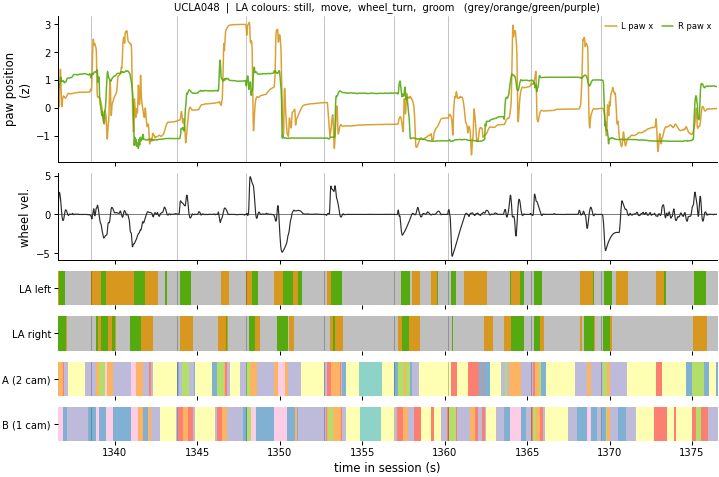

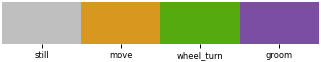

In [8]:
"""
SIDE BY SIDE: traces + LA labels + both wavelet segmentations
"""
example = FRAMES['session'].iloc[0]
sub = FRAMES[FRAMES['session'] == example].sort_values('Bin').reset_index(drop=True)
example_mouse = sub['mouse_name'].iloc[0]

WINDOW_S = 40
gocues = np.sort(sub['goCueTrigger_times'].dropna().unique())
t0 = gocues[len(gocues) // 2] - 2 if len(gocues) else sub['Bin'].iloc[0]
win = sub[(sub['Bin'] >= t0) & (sub['Bin'] < t0 + WINDOW_S)].reset_index(drop=True)
t = win['Bin'].to_numpy()

fig, axs = plt.subplots(6, 1, figsize=(ps.FIG['double'][0], 4.6), sharex=True,
                        gridspec_kw={'height_ratios': [3, 1.8, .7, .7, .7, .7], 'hspace': 0.18})

for side, col in (('l', '#D8971F'), ('r', '#54AA0E')):
    axs[0].plot(t, stats.zscore(win[f'{side}_paw_x'], nan_policy='omit'), color=col, lw=0.9,
                alpha=0.9, label=f'{side.upper()} paw x')
axs[0].legend(ncol=2, fontsize=5, frameon=False, loc='upper right')
axs[0].set_ylabel('paw position\n(z)')

axs[1].plot(t, win['avg_wheel_vel'], color=ps.STATE_INK, lw=0.7)
ps.zero_line(axs[1])
axs[1].set_ylabel('wheel vel.')

ribbon(axs[2], t, win['LA_left'].to_numpy(), 'LA left', LA_CMAP, LA_NORM)
ribbon(axs[3], t, win['LA_right'].to_numpy(), 'LA right', LA_CMAP, LA_NORM)
ribbon(axs[4], t, win['A'].to_numpy(), 'A (2 cam)', PAW_CMAP, PAW_NORM)
ribbon(axs[5], t, win['B'].to_numpy(), 'B (1 cam)', PAW_CMAP, PAW_NORM)

for ax in axs:
    ax.tick_params(labelbottom=False)
    for g in gocues[(gocues >= t[0]) & (gocues <= t[-1])]:
        ax.axvline(g, color='k', lw=0.4, alpha=0.35, zorder=0)
axs[-1].tick_params(labelbottom=True)
axs[-1].set_xlabel('time in session (s)')
axs[0].set_title(f'{example_mouse}  |  LA colours: '
                 + ',  '.join(f'{c}' for c in LA_CLASSES) + '   (grey/orange/green/purple)',
                 fontsize=6)
plt.show()

fig, ax = plt.subplots(figsize=(ps.FIG['single'][0], 0.45))
ax.imshow(np.arange(K_LA)[None, :], aspect='auto', cmap=LA_CMAP, norm=LA_NORM)
ax.set_xticks(range(K_LA))
ax.set_xticklabels(LA_CLASSES, fontsize=5)
ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)
plt.show()

---
## 2. Correlations between the segmentations

Three pairs, and they are not the same kind of comparison:

- **LA vs A** and **LA vs B** compare an 8-state unsupervised alphabet against a 4-class supervised
  one. A one-to-one matching cannot work here (8 into 4), so the score to read is the
  **modal-map accuracy** — read each wavelet state as a prediction of the LA behaviour it most
  often coincides with — alongside **ARI** and **AMI**, which need no correspondence and handle
  unequal alphabet sizes natively.
- **A vs B** is 8 against 8, so the numbers there are directly comparable to the A-vs-B notebook,
  restricted to these 19 sessions.

**The comparison that answers the question is `ARI(LA, A)` against `ARI(LA, B)`** — is the
two-camera segmentation measurably closer to a supervised account of the behaviour than the
one-camera one? The per-session paired test below is the honest version of that, with n = 19.

In [9]:
"""
PAIRWISE AGREEMENT, POOLED OVER ALL ALIGNED FRAMES
"""
PAIRS = [('A', 'LA_left', K_PAW, K_LA, 'A  vs  LA left paw'),
         ('B', 'LA_left', K_PAW, K_LA, 'B  vs  LA left paw'),
         ('A', 'LA_right', K_PAW, K_LA, 'A  vs  LA right paw'),
         ('B', 'LA_right', K_PAW, K_LA, 'B  vs  LA right paw'),
         ('A', 'LA_joint', K_PAW, K_LA ** 2, 'A  vs  LA joint (16)'),
         ('B', 'LA_joint', K_PAW, K_LA ** 2, 'B  vs  LA joint (16)'),
         ('A', 'B', K_PAW, K_PAW, 'A  vs  B')]

pair_rows, pair_counts = [], {}
for xc, yc, kx, ky, label in PAIRS:
    x = FRAMES[xc].to_numpy().astype(int)
    y = FRAMES[yc].to_numpy().astype(int)
    metrics, counts = cluster_agreement(x, y, kx, ky)
    pair_rows.append({'pair': label, **metrics})
    pair_counts[label] = counts

pairs_df = pd.DataFrame(pair_rows).set_index('pair')
display(pairs_df.style.format('{:.3f}'))

,modal-map accuracy,chance (modal-map),Cohen's kappa,adjusted Rand,adjusted MI
pair,,,,,
A vs LA left paw,0.741,0.623,0.438,0.254,0.253
B vs LA left paw,0.765,0.623,0.549,0.214,0.248
A vs LA right paw,0.723,0.619,0.473,0.258,0.245
B vs LA right paw,0.726,0.619,0.487,0.188,0.211
A vs LA joint (16),0.655,0.570,0.340,0.304,0.257
B vs LA joint (16),0.665,0.570,0.428,0.232,0.232
A vs B,0.583,0.297,0.484,0.406,0.453


,mean ARI A,mean ARI B,mean delta (B-A),sessions where A closer,n,wilcoxon p
LA reference,,,,,,
LA_left,0.262,0.221,-0.0410,18,19,7.63e-06
LA_right,0.264,0.202,-0.0621,19,19,3.81e-06
LA_joint,0.307,0.241,-0.0656,19,19,3.81e-06


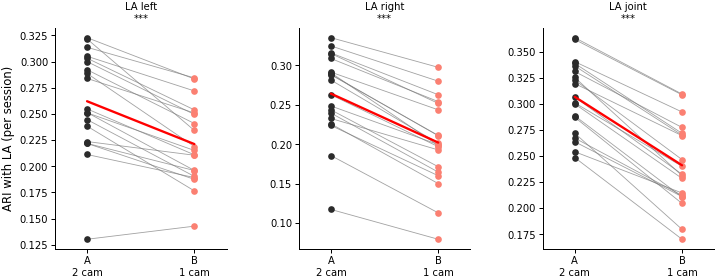

In [10]:
"""
IS A OR B CLOSER TO LA?  Per-session ARI, paired across the 19 sessions.
"""
sessions = FRAMES['session'].unique()
rows = []
for session in sessions:
    sel = (FRAMES['session'] == session).to_numpy()
    row = {'session': session,
           'mouse_name': FRAMES.loc[sel, 'mouse_name'].iloc[0], 'n_frames': int(sel.sum())}
    for yc in ('LA_left', 'LA_right', 'LA_joint'):
        y = FRAMES.loc[sel, yc].to_numpy().astype(int)[::5]
        for xc in ('A', 'B'):
            x = FRAMES.loc[sel, xc].to_numpy().astype(int)[::5]
            row[f'ARI {xc}-{yc}'] = adjusted_rand_score(x, y)
    rows.append(row)
per_session = pd.DataFrame(rows)

comp = []
for yc in ('LA_left', 'LA_right', 'LA_joint'):
    a, b = per_session[f'ARI A-{yc}'], per_session[f'ARI B-{yc}']
    comp.append({'LA reference': yc, 'mean ARI A': a.mean(), 'mean ARI B': b.mean(),
                 'mean delta (B-A)': (b - a).mean(),
                 'sessions where A closer': int((a > b).sum()), 'n': len(a),
                 'wilcoxon p': stats.wilcoxon(a, b)[1]})
comp = pd.DataFrame(comp).set_index('LA reference')
display(comp.style.format({'mean ARI A': '{:.3f}', 'mean ARI B': '{:.3f}',
                           'mean delta (B-A)': '{:+.4f}', 'wilcoxon p': '{:.3g}'}))

fig, axs = plt.subplots(1, 3, figsize=(ps.FIG['double'][0], 2.4),
                        gridspec_kw={'wspace': 0.42})
for ax, yc in zip(axs, ('LA_left', 'LA_right', 'LA_joint')):
    a, b = per_session[f'ARI A-{yc}'].to_numpy(), per_session[f'ARI B-{yc}'].to_numpy()
    for i in range(len(a)):
        ax.plot([0, 1], [a[i], b[i]], color=ps.NEUTRAL, lw=0.5, alpha=0.7, zorder=1)
    ax.plot(np.zeros(len(a)), a, 'o', ms=3, color=ps.STATE_INK, zorder=2)
    ax.plot(np.ones(len(b)), b, 'o', ms=3, color=ps.SYLLABLE['Paw 3'], zorder=2)
    ax.plot([0, 1], [a.mean(), b.mean()], color='r', lw=1.4, zorder=3)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['A\n2 cam', 'B\n1 cam'])
    ax.set_xlim(-0.3, 1.3)
    ax.set_title(f'{yc.replace("_", " ")}\n{ps.stars(comp.loc[yc, "wilcoxon p"])}', fontsize=6)
axs[0].set_ylabel('ARI with LA (per session)')
plt.show()

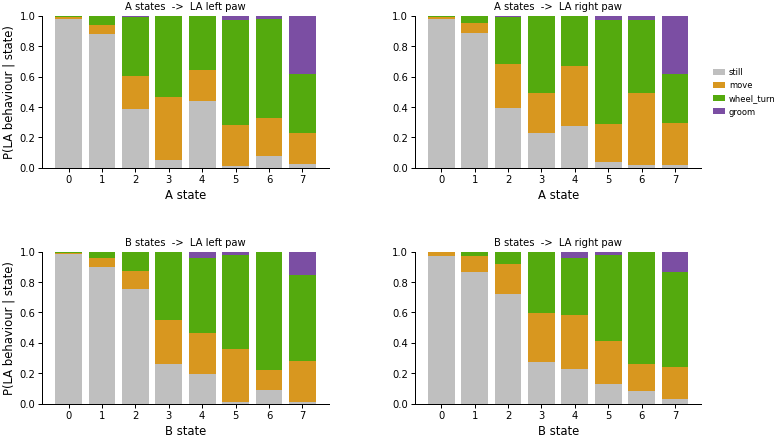

In [11]:
"""
WHAT EACH WAVELET STATE MEANS: P(LA behaviour | wavelet state)

This is the interpretation the unsupervised states otherwise lack.
"""
fig, axs = plt.subplots(2, 2, figsize=(ps.FIG['double'][0], 4.2),
                        gridspec_kw={'wspace': 0.3, 'hspace': 0.55})
for row, seg in enumerate(('A', 'B')):
    for col, paw in enumerate(('LA_left', 'LA_right')):
        ax = axs[row, col]
        counts = pair_counts[f'{seg}  vs  LA {paw.split("_")[1]} paw']
        frac = counts / counts.sum(axis=1, keepdims=True)
        bottom = np.zeros(K_PAW)
        for c in range(K_LA):
            ax.bar(np.arange(K_PAW), frac[:, c], bottom=bottom, color=LA_COLORS[c],
                   label=LA_CLASSES[c], width=0.8)
            bottom += frac[:, c]
        ax.set_xticks(range(K_PAW))
        ax.set_ylim(0, 1)
        ax.set_title(f'{seg} states  ->  LA {paw.split("_")[1]} paw', fontsize=6)
        ax.set_xlabel(f'{seg} state')
        if col == 0:
            ax.set_ylabel('P(LA behaviour | state)')
axs[0, 1].legend(fontsize=5, frameon=False, loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.show()

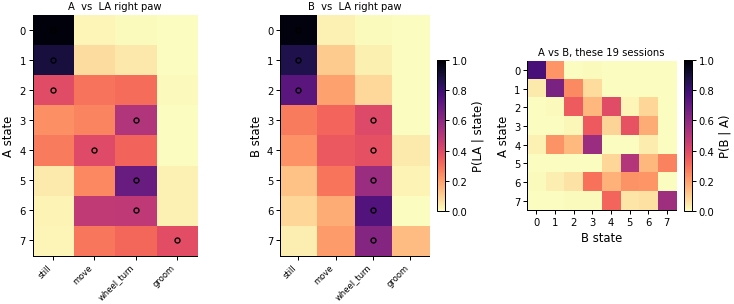

In [12]:
"""
THE SAME AS HEATMAPS, PLUS A VS B ON THESE SESSIONS
"""
fig, axs = plt.subplots(1, 3, figsize=(ps.FIG['double'][0], 2.6),
                        gridspec_kw={'wspace': 0.5})
for ax, label, ylab in [(axs[0], 'A  vs  LA right paw', 'A state'),
                        (axs[1], 'B  vs  LA right paw', 'B state')]:
    counts = pair_counts[label]
    frac = counts / counts.sum(axis=1, keepdims=True)
    im = ax.imshow(frac, cmap='magma_r', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(K_LA))
    ax.set_xticklabels(LA_CLASSES, rotation=45, ha='right', fontsize=5)
    ax.set_yticks(range(K_PAW))
    ax.set_ylabel(ylab)
    ax.set_title(label, fontsize=6)
    for i in range(K_PAW):
        ax.plot(frac[i].argmax(), i, 'o', ms=3, mfc='none', mec='k', mew=0.8)
fig.colorbar(im, ax=axs[1], fraction=0.046, label='P(LA | state)')

counts = pair_counts['A  vs  B']
frac = counts / counts.sum(axis=1, keepdims=True)
im = axs[2].imshow(frac, cmap='magma_r', vmin=0, vmax=1)
axs[2].set_xticks(range(K_PAW))
axs[2].set_yticks(range(K_PAW))
axs[2].set_xlabel('B state')
axs[2].set_ylabel('A state')
axs[2].set_title(f'A vs B, these {len(sessions)} sessions', fontsize=6)
fig.colorbar(im, ax=axs[2], fraction=0.046, label='P(B | A)')
plt.show()

---
## 3. Predictability of task events

The same decoding setup as `../1_camera_setup/3_segmentation_comparison.ipynb` section 4, but with
LA added and run on the frames rather than the pre-binned syllables:

- **Features** — per trial, the fraction of frames spent in each state, separately per epoch. So
  `4 epochs x k states`, and `k` differs between segmentations: LA left / LA right have 4, A and B
  have 8, LA joint has 16. **The feature count is printed next to every row, and the bias runs
  toward the larger alphabet** — LA joint gets 64 features against A's and B's 32, so it should not
  be read as "LA wins". The 4-class LA rows are the dimension-conservative comparison.
- **Targets** — choice, stimulus side (choice flipped on error trials), feedback, contrast, zero
  contrast, block, all taken from the LA file's own trial columns.
- **Cross-validation** — `GroupKFold` by session. With only 19 sessions that is ~4 sessions per
  held-out fold, so these numbers are far noisier than the 332-session versions.

In [13]:
"""
TASK DECODING: BUILD THE TRIAL TABLE
"""
SEGMENTATIONS = {'LA left (4)': ('LA_left', K_LA),
                 'LA right (4)': ('LA_right', K_LA),
                 'LA joint (16)': ('LA_joint', K_LA ** 2),
                 'A - two camera (8)': ('A', K_PAW),
                 'B - one camera (8)': ('B', K_PAW)}
N_SPLITS = 5

# only frames inside one of the four epochs carry trial-level meaning
ep = FRAMES['broader_label'].map({e: i for i, e in enumerate(EPOCHS)})
inside = ep.notna().to_numpy()
ep = ep[inside].to_numpy().astype(int)
F = FRAMES[inside]

trial_key = F['session'] + ' ' + F['trial_id'].astype(str)
trial_code, trial_names = pd.factorize(trial_key)

tm = (pd.DataFrame({'k': trial_key.to_numpy(), 'session': F['session'].to_numpy(),
                    'mouse_name': F['mouse_name'].to_numpy(), 'correct': F['correct'].to_numpy(),
                    'choice': F['choice'].to_numpy(), 'contrast': F['contrast'].to_numpy(),
                    'block': F['block'].to_numpy()})
        .drop_duplicates('k').set_index('k').loc[trial_names])

flip = {'left': 'right', 'right': 'left'}
trials = pd.DataFrame({
    'session': tm['session'].to_numpy(), 'mouse_name': tm['mouse_name'].to_numpy(),
    'feedback': np.where(tm['correct'].to_numpy() == 1., 'correct', 'incorrect'),
    'choice': tm['choice'].to_numpy(),
    'contrast': tm['contrast'].astype(str).to_numpy(),
    'block': tm['block'].astype(str).to_numpy(),
})
trials['stim_side'] = np.where(trials['feedback'] == 'correct', trials['choice'],
                               pd.Series(trials['choice']).map(flip))
trials['zero_contrast'] = np.where(tm['contrast'].to_numpy() == 0., 'zero', 'nonzero')


def trial_features(state_col, k):
    """(n_trials, 4 * k) per-epoch occupancy of each state."""
    st = F[state_col].to_numpy().astype(int)
    X = np.zeros((len(trial_names), len(EPOCHS), k), dtype=np.float32)
    np.add.at(X, (trial_code, ep, st), 1)
    X /= np.maximum(X.sum(2, keepdims=True), 1)
    return X.reshape(len(trial_names), -1)


FEATURES = {name: trial_features(col, k) for name, (col, k) in SEGMENTATIONS.items()}
print(f'{len(trials):,} trials, {trials["session"].nunique()} sessions')
for name, X in FEATURES.items():
    print(f'  {name:22s} {X.shape[1]:3d} features')

10,294 trials, 19 sessions
  LA left (4)             16 features
  LA right (4)            16 features
  LA joint (16)           64 features
  A - two camera (8)      32 features
  B - one camera (8)      32 features


In [14]:
"""
TASK DECODING: RUN IT
"""
TARGETS = {
    'choice (L/R)':        trials['choice'],
    'stimulus side (L/R)': trials['stim_side'],
    'feedback (corr/err)': trials['feedback'],
    'contrast (5-way)':    trials['contrast'],
    'zero contrast':       trials['zero_contrast'],
    'block (3-way)':       trials['block'],
}
groups = trials['session'].to_numpy()

dec_rows = []
for target, y_ser in TARGETS.items():
    y = y_ser.to_numpy()
    chance = 1 / len(np.unique(y))
    for name, X in FEATURES.items():
        clf = make_pipeline(StandardScaler(),
                            LogisticRegression(max_iter=500, class_weight='balanced'))
        pred = cross_val_predict(clf, X, y, cv=GroupKFold(N_SPLITS), groups=groups,
                                 n_jobs=N_SPLITS)
        dec_rows.append({'target': target, 'segmentation': name, 'n_features': X.shape[1],
                         'chance': chance, 'bal.acc': balanced_accuracy_score(y, pred)})
    best = max((r for r in dec_rows if r['target'] == target), key=lambda r: r['bal.acc'])
    print(f'{target:22s} chance {chance:.3f}   best: {best["segmentation"]} '
          f'{best["bal.acc"]:.3f}')

decoding = pd.DataFrame(dec_rows)
table = decoding.pivot(index='target', columns='segmentation', values='bal.acc')
table = table[list(SEGMENTATIONS)].loc[list(TARGETS)]
table['chance'] = decoding.groupby('target')['chance'].first().loc[list(TARGETS)]
display(table.style.format('{:.3f}').background_gradient(cmap='magma_r', axis=1,
                                                         subset=list(SEGMENTATIONS)))

choice (L/R)           chance 0.500   best: A - two camera (8) 0.558
stimulus side (L/R)    chance 0.500   best: LA joint (16) 0.516
feedback (corr/err)    chance 0.500   best: LA joint (16) 0.699
contrast (5-way)       chance 0.200   best: LA joint (16) 0.326
zero contrast          chance 0.500   best: LA left (4) 0.701
block (3-way)          chance 0.333   best: A - two camera (8) 0.398


segmentation,LA left (4),LA right (4),LA joint (16),A - two camera (8),B - one camera (8),chance
target,,,,,,
choice (L/R),0.497,0.504,0.528,0.558,0.499,0.500
stimulus side (L/R),0.504,0.507,0.516,0.514,0.515,0.500
feedback (corr/err),0.687,0.695,0.699,0.639,0.632,0.500
contrast (5-way),0.324,0.309,0.326,0.288,0.300,0.200
zero contrast,0.701,0.669,0.700,0.583,0.611,0.500
block (3-way),0.360,0.356,0.357,0.398,0.365,0.333


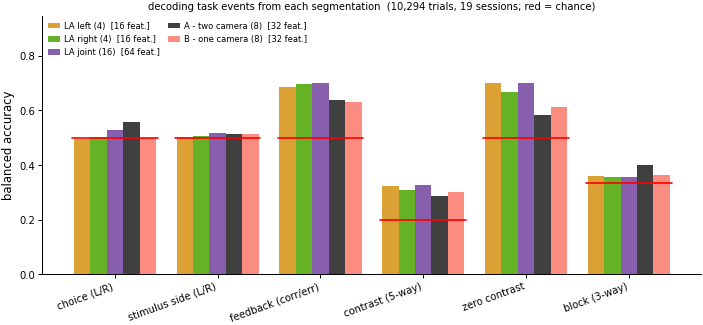

In [15]:
"""
TASK DECODING: THE FIGURE
"""
COLS = {'LA left (4)': LA_COLORS[1], 'LA right (4)': LA_COLORS[2],
        'LA joint (16)': LA_COLORS[3], 'A - two camera (8)': ps.STATE_INK,
        'B - one camera (8)': ps.SYLLABLE['Paw 3']}

fig, ax = plt.subplots(figsize=(ps.FIG['double'][0], 2.8))
xx = np.arange(len(TARGETS))
w = 0.16
for i, name in enumerate(SEGMENTATIONS):
    vals = [table.loc[t, name] for t in TARGETS]
    ax.bar(xx + (i - 2) * w, vals, width=w, color=COLS[name], alpha=0.9,
           label=f'{name}  [{FEATURES[name].shape[1]} feat.]')
for x, t in zip(xx, TARGETS):
    ax.plot([x - 2.6 * w, x + 2.6 * w], [table.loc[t, 'chance']] * 2, color='r', lw=1.0, zorder=3)
ax.set_xticks(xx)
ax.set_xticklabels(list(TARGETS), rotation=20, ha='right')
ax.set_ylabel('balanced accuracy')
ax.legend(fontsize=5, frameon=False, ncol=2, loc='upper left')
ax.set_ylim(0, min(1.0, table[list(SEGMENTATIONS)].to_numpy().max() * 1.35))
ax.set_title(f'decoding task events from each segmentation  '
             f'({len(trials):,} trials, {trials["session"].nunique()} sessions; '
             f'red = chance)', fontsize=6)
plt.show()

---
## Reading this notebook

**On the correlations.** The ceiling is LA's own cross-camera agreement, computed at the top: no
unsupervised segmentation can match "the LA label" better than LA matches itself. Read
`ARI(LA, A)` and `ARI(LA, B)` against that number, not against 1. The decisive comparison is
A-vs-B on the **right paw** reference: B never saw the right paw, so if `ARI(B, LA_right)` holds up
against `ARI(A, LA_right)`, the wheel is standing in for the second camera even by the standards of
a supervised labeller. The left-paw reference is the calibration, exactly as in the R^2 analysis of
the other notebook.

**When the metrics disagree, that is the finding.** `ARI` and the `modal-map accuracy` /
`Cohen's kappa` pair can point in opposite directions, and they did in the run this notebook was
written against: A had the higher ARI with LA while B had the higher modal-map accuracy and kappa.
That is not a contradiction. Modal-map accuracy asks *does each state predict the right LA label*,
which rewards states that sit cleanly inside one LA class. ARI asks *do the two carve the frames up
the same way*, counting every pair of frames the two disagree about grouping. So B's states are
individually purer with respect to LA's four classes, while A's partition is the better match to
LA's partition. Read it as B splitting LA's classes more cleanly and A tracking their boundaries
more faithfully — and quote whichever one answers the question you are actually asking.

**On `P(LA behaviour | state)`.** This is the only place in the pipeline where the unsupervised
states acquire names. Two things to look for: whether any wavelet state maps cleanly onto
`wheel_turn` (that would be the state doing the task's work), and whether `groom` — a behaviour the
wavelets were never designed to isolate — gets its own state or is smeared across several. A state
whose distribution is flat across the four behaviours is a state the supervised account does not
recognise, and is worth inspecting directly in the ribbons.

**On the decoding, and what it cannot settle.** The alphabets are different sizes and the
comparison is *not* dimension-matched: LA joint has 64 features where A and B have 32, and more
features raise accuracy on their own. So the defensible reads are (i) A against B, which are both
8 states and 32 features, and (ii) LA left / LA right against each other. Comparing LA joint to
anything requires either collapsing it or expanding A and B, neither of which is done here.

**And the caveat that dominates everything.** `n = 19` sessions, and `GroupKFold` leaves out ~4 of
them per fold. The 332-session A-vs-B result in the other notebook is the reliable one; this
notebook's job is to add the *supervised* reference, not to re-measure A against B with a twentieth
of the data. A per-session paired test on 19 sessions can detect a consistent effect but will miss
a small one, so a null here is not evidence of no difference.

**Extensions worth the effort, roughly in order:**

1. **Use LA's ensemble variance.** The file carries `*_ens_var` for every class and camera, i.e. a
   per-frame confidence. Restricting the comparison to confident LA frames would sharpen every
   number here, and the gap between confident and all frames is itself informative.
2. **Dwell times and transitions.** LA is frame-independent (argmax per frame, no temporal model),
   so it should flicker far more than the wavelet segmentations. Comparing dwell-time distributions
   would say how much of the disagreement is boundary noise rather than substance.
3. **Extend LA to more sessions.** 31 of the 50 LA sessions have no `k = 8` A/B states. Running the
   existing cluster propagation on those (`../3.3_wavelet_clusters.ipynb` and
   `../3.3_left_paw_wheel_clusters.ipynb`) would take this from 19 sessions to 50 and make the
   per-session statistics worth quoting.

### What the run this notebook was written against found

Recorded so a re-run can be compared against it; every number comes from the cells above,
19 sessions / 15 mice / 3.21M aligned frames / 10,294 trials.

**Alignment** was exact: 100.0% of LA frames matched an A and a B state on `Bin` in all 19
sessions. **LA's own ceiling**: cross-camera agreement 0.905 (left paw) and 0.885 (right paw),
ARI 0.79 / 0.73; the mismatched control pairings fell to 0.786 / 0.790, confirming `LA_PAW_COL`.

**A is closer to LA than B, consistently.** Per-session ARI favoured A in 18/19 sessions against
the left-paw reference and **19/19** against the right-paw and joint references (Wilcoxon
p < 1e-5 in all three; mean ARI delta -0.041 to -0.066). This is the strongest evidence in either
notebook that the second camera carries something real: a *supervised* labeller agrees more with
the two-camera segmentation, and it does so in essentially every session. It sits alongside the
opposite-signed modal-map/kappa result discussed above.

**The states got names.** State 0 is almost pure `still` and state 1 nearly so; states 5 and 6 are
`wheel_turn`-dominated; **state 7 is the grooming state** — 38% `groom` under A but only 15% under
B. Grooming is a bilateral paw movement that leaves no trace on the wheel, so the one-camera
segmentation cannot isolate it. That is a concrete, mechanistic account of what B loses, and it is
more informative than any single agreement number.

**Task decoding split by variable.** A was the only segmentation to decode `choice` above chance
(0.558); **B sat at chance (0.4995)** on these 19 sessions — a much starker version of the small
choice deficit seen across all 332 sessions in the other notebook, and the small-n caveat cuts both
ways here. A also led on `block` (0.398). But LA beat both on `feedback` (0.699 vs 0.639 / 0.632),
`zero contrast` (0.701 vs 0.583 / 0.611) and `contrast`, and did so with **fewer** features
(16 vs 32) — so dimensionality does not explain it. Note that `feedback` reaches 0.911 in the other
notebook, where the syllables include the **lick** state; paw states alone get to 0.70, and
post-feedback licking is the difference.